# Introduction to Machine Learning — Class 7
## Cross-Validation, Bias–Variance & Learning Curves

**Input dataset:** `adult_classification_v1.csv`  
**Problem:** Binary classification  

---

### Learning goals
- Understand why a single train/validation split is insufficient
- Apply cross-validation for model assessment
- Diagnose bias vs variance
- Interpret learning curves
- Make informed decisions about model complexity

> **Key idea:** Generalization matters more than performance on a single split.

<div style="margin-left: 2em; font-size: 0.9em; font-style: italic;">
An AI language model (ChatGPT by OpenAI) was used to support the creation of practical class materials. 
All arguments, outputs, and final wording were critically reviewed, edited, and validated by the author 
prior to use with students.
</div>

## 0. Data context

You will continue working with the **same binary classification dataset**.

The data has not changed.  
What changes now is **how we reason about reliability and generalization**.


In [3]:
DATA_PATH = "adult_classification_v1.csv"


## 1. Imports


In [5]:
# TODO: import required libraries
# numpy, pandas, matplotlib
# sklearn: StratifiedKFold, cross_val_score
# sklearn: LogisticRegression, DecisionTreeClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

In [6]:
# Auto-check
import importlib
_required = ["numpy", "pandas", "sklearn", "matplotlib"]
missing = [m for m in _required if importlib.util.find_spec(m) is None]
assert not missing, f"Missing packages: {missing}"
print("Auto-check passed.")


Auto-check passed.


## 2. Load data

### Tasks
- Load the dataset
- Separate features and target
- Reflect on data scaling


In [7]:
# TODO: load dataset
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=["income"])
y = df["income"]

print(X.shape, y.value_counts())

(45222, 62) income
0    34014
1    11208
Name: count, dtype: int64


In [9]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Why one split is not enough

### Task
- Train a model using different random splits
- Observe variability in performance

**Reflection**
- Are results stable?


In [10]:
# TODO: multiple random splits experiment
scores = []
for seed in range(10):
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, test_size=0.2, random_state=seed, stratify=y
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    scores.append(model.score(X_val, y_val))

print("Scores:", [round(s, 4) for s in scores])
print(f"Mean: {np.mean(scores):.4f}  Std: {np.std(scores):.4f}")

Scores: [0.8503, 0.8498, 0.8489, 0.8534, 0.8472, 0.8471, 0.847, 0.8515, 0.8506, 0.8491]
Mean: 0.8495  Std: 0.0020


## 4. Cross-validation

### Task
- Apply stratified K-fold cross-validation
- Compute mean and standard deviation of performance

**Reflection**
- What does variability tell you?


In [12]:
# TODO: cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

model_lr = LogisticRegression(max_iter=1000)
scores_cv = cross_val_score(model_lr, X_scaled, y, cv=cv, scoring="accuracy")

print("Fold scores:", scores_cv.round(4))
print(f"Mean: {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")

Fold scores: [0.8499 0.832  0.8514 0.847  0.8523 0.8589 0.8545 0.843  0.8567 0.8412]
Mean: 0.8487 ± 0.0077


## 5. Bias vs variance

### Task
- Compare models of different complexity
- Identify high bias vs high variance behaviour

**Reflection**
- How does model complexity affect errors?


In [13]:
# TODO: bias-variance comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Tree (max_depth=3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Tree (max_depth=None)": DecisionTreeClassifier(max_depth=None, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
    print(f"{name:30s}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}")

Logistic Regression             Mean: 0.8485  Std: 0.0046
Tree (max_depth=3)              Mean: 0.8399  Std: 0.0049
Tree (max_depth=None)           Mean: 0.8121  Std: 0.0064


In [14]:
for name, model in models.items():
    train_scores = []
    val_scores = []
    for train_idx, val_idx in cv.split(X_scaled, y):
        model.fit(X_scaled[train_idx], y.iloc[train_idx])
        train_scores.append(model.score(X_scaled[train_idx], y.iloc[train_idx]))
        val_scores.append(model.score(X_scaled[val_idx], y.iloc[val_idx]))
    print(f"{name:30s}  Train: {np.mean(train_scores):.4f}  Val: {np.mean(val_scores):.4f}")

Logistic Regression             Train: 0.8490  Val: 0.8485
Tree (max_depth=3)              Train: 0.8399  Val: 0.8399
Tree (max_depth=None)           Train: 0.9999  Val: 0.8121


## 6. Learning curves

### Task
- Plot learning curves for one model
- Interpret training vs validation curves

**Reflection**
- What problem does the model have?


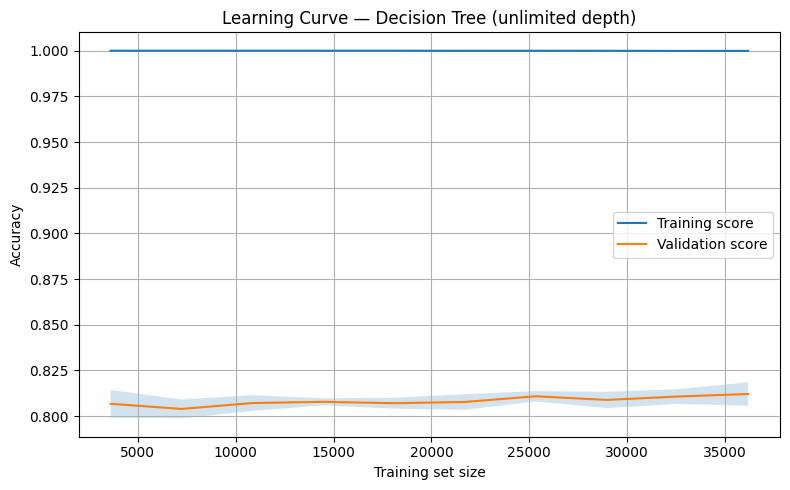

In [15]:
# TODO: learning curves
model = DecisionTreeClassifier(max_depth=None, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_scaled, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy",
    n_jobs=-1,
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation score")
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Decision Tree (unlimited depth)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

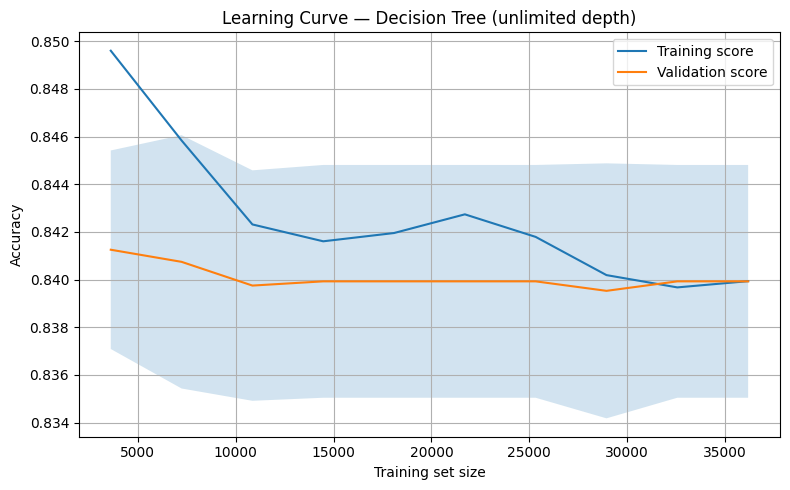

In [16]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_scaled, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy",
    n_jobs=-1,
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation score")
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Decision Tree (unlimited depth)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_scaled, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy",
    n_jobs=-1,
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation score")
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve — Decision Tree (unlimited depth)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Critical reflection

Answer in Markdown:
- Why is cross-validation important?
- How do bias and variance affect generalization?
- How can learning curves guide model improvement?


### Reflection

(Write your answers here.)
